# Titanic Dataset Analysis

## 1. Project Overview
Exploratory data analysis (EDA) of the Kaggle Titanic **training** dataset (891 passengers), using `pandas` and `matplotlib`. The notebook checks data quality, handles missing values and explores how survival relates to sex, passenger class, age, family size and fare. No machine-learning model is built.

The results are observed survival rates in this dataset. They describe associations and do not show what *caused* survival.

## 2. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 3. Load Dataset

In [2]:
DATA_PATH = Path("../data/train.csv")
if not DATA_PATH.exists():          # notebook started from the repository root
    DATA_PATH = Path("data/train.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Dataset Overview

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


The file has 891 passenger records and 12 columns. `Survived` is the recorded outcome (0 = did not survive, 1 = survived). The file is not a complete passenger list of the ship.

| Column | Description |
|---|---|
| `PassengerId` | Unique passenger identifier |
| `Survived` | Outcome (0 = No, 1 = Yes) |
| `Pclass` | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `Name`, `Ticket` | Passenger name and ticket number |
| `Sex`, `Age` | Sex and age in years |
| `SibSp`, `Parch` | Siblings/spouses and parents/children aboard |
| `Fare` | Passenger fare |
| `Cabin` | Cabin number |
| `Embarked` | Port of embarkation (C, Q or S) |

In [4]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


## 5. Data Cleaning and Data Quality

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("PassengerId is unique:", df["PassengerId"].is_unique)
print()
for column in ["Survived", "Pclass", "Sex", "Embarked"]:
    print(f"{column}: {sorted(df[column].dropna().unique().tolist())}")
print()
print("Age range :", df["Age"].min(), "to", df["Age"].max())
print("Fare range:", df["Fare"].min(), "to", round(df["Fare"].max(), 2))
print("Rows with Fare = 0:", (df["Fare"] == 0).sum())

Duplicate rows: 0
PassengerId is unique: True

Survived: [0, 1]
Pclass: [1, 2, 3]
Sex: ['female', 'male']
Embarked: ['C', 'Q', 'S']

Age range : 0.42 to 80.0
Fare range: 0.0 to 512.33
Rows with Fare = 0: 15


There are no duplicate rows, `PassengerId` is unique and the categorical columns contain only the expected values. 15 passengers have a fare of exactly 0; this cannot be verified from the data, so it is kept as recorded. `Fare` is strongly right-skewed, so medians are used alongside means.

## 6. Missing Value Analysis

In [6]:
missing_values = df.isna().sum()
missing_summary = pd.DataFrame({
    "Missing": missing_values,
    "Missing (%)": (missing_values / len(df) * 100).round(1),
})
missing_summary[missing_summary["Missing"] > 0]

,Missing,Missing (%)
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


| Column | Missing | Treatment |
|---|---|---|
| `Cabin` | 687 (77.1%) | Dropped: too sparse to analyse |
| `Age` | 177 (19.9%) | Not imputed: age analysis uses only the 714 known ages |
| `Embarked` | 2 | Not used in this analysis |

`Name` and `Ticket` are identifiers that are not analysed, so they are dropped. `SibSp` and `Parch` are combined into `FamilySize` (the passenger plus siblings, spouses, parents and children aboard).

In [7]:
passengers = df.drop(columns=["Name", "Ticket", "Cabin"]).copy()
passengers["FamilySize"] = passengers["SibSp"] + passengers["Parch"] + 1

age_known = passengers.dropna(subset=["Age"]).copy()

print("Rows used  ->  all:", len(passengers), "| age analysis:", len(age_known))

Rows used  ->  all: 891 | age analysis: 714


## 7. Exploratory Data Analysis

In [8]:
def summarize_survival(data, by):
    """Passengers, survivors and survival rate for each group."""
    grouped = data.groupby(by, observed=True)
    return pd.DataFrame({
        "Passengers": grouped.size(),
        "Survivors": grouped["Survived"].sum(),
        "Survival rate (%)": (grouped["Survived"].mean() * 100).round(1),
    })


BAR_COLOR = "#3a7ca5"


def add_bar_labels(ax, bars, labels):
    ax.bar_label(bars, labels=labels, padding=3)

### 7.1 Overall survival distribution

Survived
Did not survive (0)    549
Survived (1)           342

Overall survival rate: 38.4%


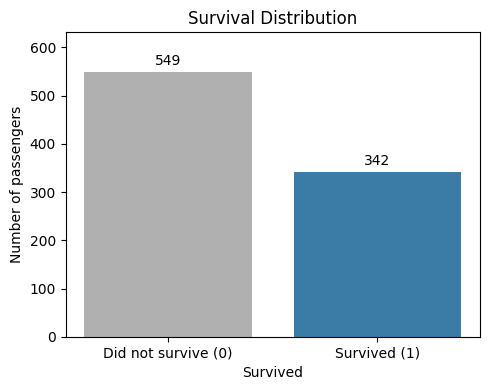

In [9]:
survival_counts = passengers["Survived"].value_counts().sort_index()
print(survival_counts.rename({0: "Did not survive (0)", 1: "Survived (1)"}).to_string())
print(f"\nOverall survival rate: {passengers['Survived'].mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Did not survive (0)", "Survived (1)"], survival_counts.values, color=["#b0b0b0", BAR_COLOR])
add_bar_labels(ax, bars, [str(v) for v in survival_counts.values])
ax.set_title("Survival Distribution")
ax.set_xlabel("Survived")
ax.set_ylabel("Number of passengers")
ax.set_ylim(0, survival_counts.max() * 1.15)
plt.tight_layout()
plt.show()

### 7.2 Survival by sex

        Passengers  Survivors  Survival rate (%)
Sex                                             
female         314        233               74.2
male           577        109               18.9


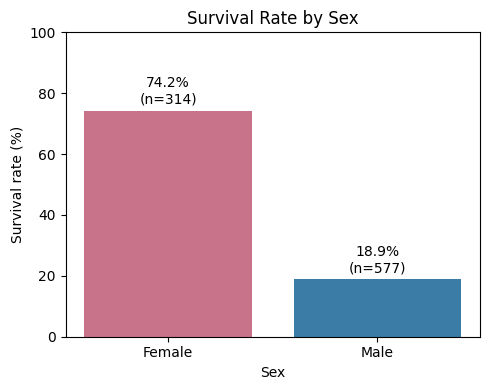

In [10]:
survival_by_sex = summarize_survival(passengers, "Sex")
print(survival_by_sex)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(survival_by_sex.index.str.capitalize(), survival_by_sex["Survival rate (%)"], color=["#c9738a", BAR_COLOR])
add_bar_labels(ax, bars, [f"{v:.1f}%\n(n={n})" for v, n in zip(survival_by_sex["Survival rate (%)"], survival_by_sex["Passengers"])])
ax.set_title("Survival Rate by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival rate (%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### 7.3 Survival by passenger class

        Passengers  Survivors  Survival rate (%)
Pclass                                          
1              216        136               63.0
2              184         87               47.3
3              491        119               24.2

Survival rate (%) by class and sex:
Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5


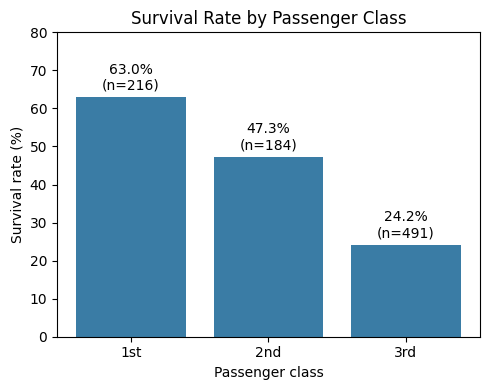

In [11]:
survival_by_class = summarize_survival(passengers, "Pclass")
print(survival_by_class)
print()
print("Survival rate (%) by class and sex:")
print(passengers.pivot_table(index="Pclass", columns="Sex", values="Survived", aggfunc="mean").mul(100).round(1))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["1st", "2nd", "3rd"], survival_by_class["Survival rate (%)"], color=BAR_COLOR)
add_bar_labels(ax, bars, [f"{v:.1f}%\n(n={n})" for v, n in zip(survival_by_class["Survival rate (%)"], survival_by_class["Passengers"])])
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate (%)")
ax.set_ylim(0, 80)
plt.tight_layout()
plt.show()

Survival falls with class overall (63.0% / 47.3% / 24.2%), and the 1st-class rate is higher than the 3rd-class rate for women (96.8% vs 50.0%) and for men (36.9% vs 13.5%).

### 7.4 Age analysis

          count  mean  median
Survived                     
0           424  30.6    28.0
1           290  28.3    28.0

          Passengers  Survivors  Survival rate (%)
AgeGroup                                          
Under 16          83         49               59.0
16-29            301        107               35.5
30-49            256        107               41.8
50+               74         27               36.5


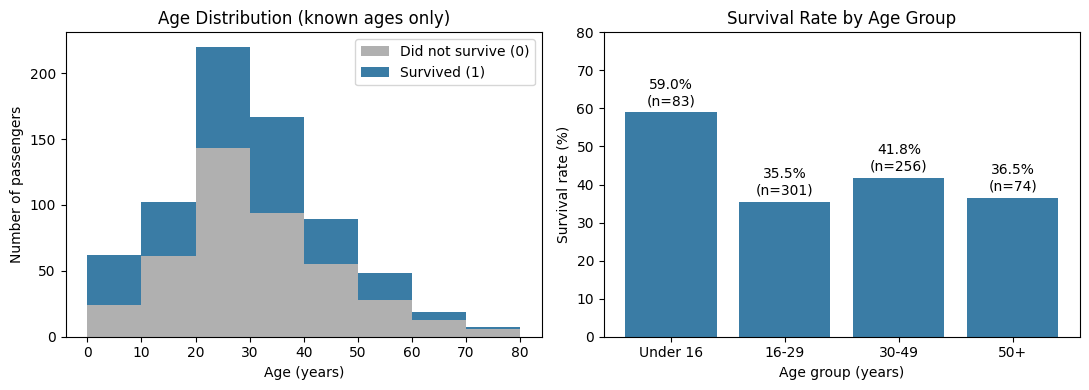

In [12]:
print(age_known.groupby("Survived")["Age"].agg(["count", "mean", "median"]).round(1))

age_known["AgeGroup"] = pd.cut(
    age_known["Age"],
    bins=[0, 16, 30, 50, 200],
    right=False,
    labels=["Under 16", "16-29", "30-49", "50+"],
)
survival_by_age_group = summarize_survival(age_known, "AgeGroup")
print()
print(survival_by_age_group)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4))

ax_left.hist(
    [age_known.loc[age_known["Survived"] == 0, "Age"], age_known.loc[age_known["Survived"] == 1, "Age"]],
    bins=range(0, 90, 10), stacked=True, color=["#b0b0b0", BAR_COLOR], label=["Did not survive (0)", "Survived (1)"],
)
ax_left.set_title("Age Distribution (known ages only)")
ax_left.set_xlabel("Age (years)")
ax_left.set_ylabel("Number of passengers")
ax_left.legend()

bars = ax_right.bar(survival_by_age_group.index.astype(str), survival_by_age_group["Survival rate (%)"], color=BAR_COLOR)
add_bar_labels(ax_right, bars, [f"{v:.1f}%\n(n={n})" for v, n in zip(survival_by_age_group["Survival rate (%)"], survival_by_age_group["Passengers"])])
ax_right.set_title("Survival Rate by Age Group")
ax_right.set_xlabel("Age group (years)")
ax_right.set_ylabel("Survival rate (%)")
ax_right.set_ylim(0, 80)

plt.tight_layout()
plt.show()

Among the 714 passengers with a known age, children under 16 have the highest survival rate (59.0%, 49 of 83). Survivors are slightly younger on average (28.3 vs 30.6 years).

### 7.5 Family-size analysis

            Passengers  Survivors  Survival rate (%)
FamilySize                                          
1                  537        163               30.4
2                  161         89               55.3
3                  102         59               57.8
4                   29         21               72.4
5                   15          3               20.0
6                   22          3               13.6
7                   12          4               33.3
8                    6          0                0.0
11                   7          0                0.0


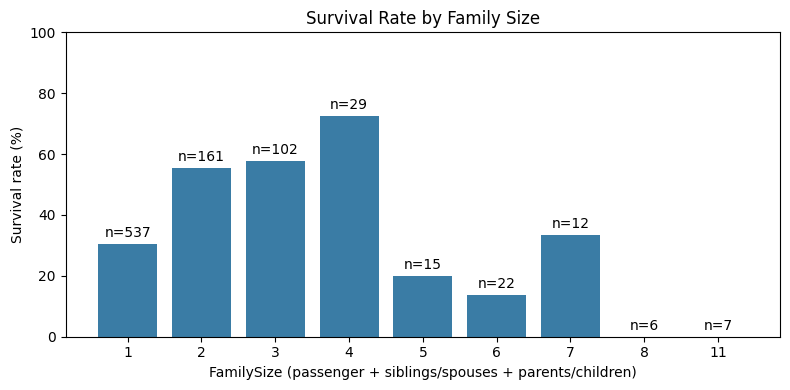

In [13]:
survival_by_family_size = summarize_survival(passengers, "FamilySize")
print(survival_by_family_size)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(survival_by_family_size.index.astype(str), survival_by_family_size["Survival rate (%)"], color=BAR_COLOR)
add_bar_labels(ax, bars, [f"n={n}" for n in survival_by_family_size["Passengers"]])
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("FamilySize (passenger + siblings/spouses + parents/children)")
ax.set_ylabel("Survival rate (%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Passengers travelling alone have a survival rate of 30.4% (n=537), family sizes 2 to 4 have 55.3% to 72.4%, and sizes 5 and above have 0.0% to 33.3%. The larger groups are small (at most 22 passengers each), so their rates are less reliable.

### 7.6 Fare analysis

In [14]:
print(passengers.groupby("Pclass")["Fare"].agg(["count", "mean", "median"]).round(2))

passengers["FareQuartile"] = pd.qcut(
    passengers["Fare"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)
print()
print("Survival by fare quartile:")
print(summarize_survival(passengers, "FareQuartile"))

        count   mean  median
Pclass                      
1         216  84.15   60.29
2         184  20.66   14.25
3         491  13.68    8.05

Survival by fare quartile:
              Passengers  Survivors  Survival rate (%)
FareQuartile                                          
Q1 (lowest)          223         44               19.7
Q2                   224         68               30.4
Q3                   222        101               45.5
Q4 (highest)         222        129               58.1


Median fares fall sharply with class (60.29 in 1st, 14.25 in 2nd and 8.05 in 3rd class). Survival rises from 19.7% in the lowest fare quartile to 58.1% in the highest. Fare and class are closely related, so this is not a separate effect.

## 8. Key Findings
All findings are observed rates in this dataset and do not establish causes.

1. **Overall:** 342 of 891 passengers (38.4%) survived.
2. **Sex:** 74.2% of women (233 of 314) survived versus 18.9% of men (109 of 577).
3. **Class:** survival was 63.0% in 1st class, 47.3% in 2nd and 24.2% in 3rd. The 1st-class rate is higher than the 3rd-class rate for both women and men.
4. **Age:** children under 16 had the highest group survival rate (59.0%); survivors were slightly younger on average (28.3 vs 30.6 years). Age is known for 714 passengers only.
5. **Family size:** passengers travelling alone survived at 30.4%, sizes 2 to 4 at 55.3% to 72.4%, and sizes 5 and above at 0.0% to 33.3% (small groups).
6. **Fare:** survival rises with fare quartile (19.7% to 58.1%), but fare is closely tied to passenger class.
7. **Data quality:** `Cabin` (77.1% missing) was dropped and the 177 missing ages were left out of the age analysis rather than imputed.